<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [2]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-06-03 10:01:48--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite.2’

survey-results-publ 100%[===================>] 201.62M  42.0MB/s    in 4.6s    

2026-06-03 10:01:56 (43.9 MB/s) - ‘survey-results-public.sqlite.2’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [3]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 79.1 MB/s eta 0:00:00:00:01


In [4]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 167.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 168.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 148.8 MB/s eta 0:00:00


In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


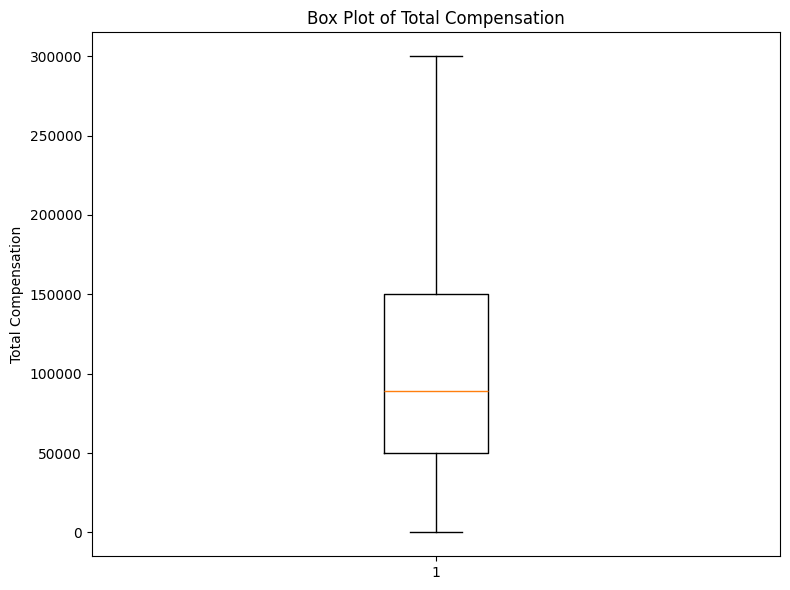

In [24]:
QUERY = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""

df_CT = pd.read_sql_query(QUERY, conn)

# Convert CompTotal to numeric
df_CT["CompTotal"] = pd.to_numeric(df_CT["CompTotal"], errors="coerce")

# Remove missing values
df_CT = df_CT.dropna(subset=["CompTotal"])

# Remove unrealistic/extreme values so the box plot is readable
df_CT = df_CT[
    (df_CT["CompTotal"] > 0) &
    (df_CT["CompTotal"] <= 500000)
]

# Create box plot
plt.figure(figsize=(8, 6))

plt.boxplot(df_CT["CompTotal"], vert=True, showfliers=False)

plt.title("Box Plot of Total Compensation")
plt.ylabel("Total Compensation")

plt.tight_layout()
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


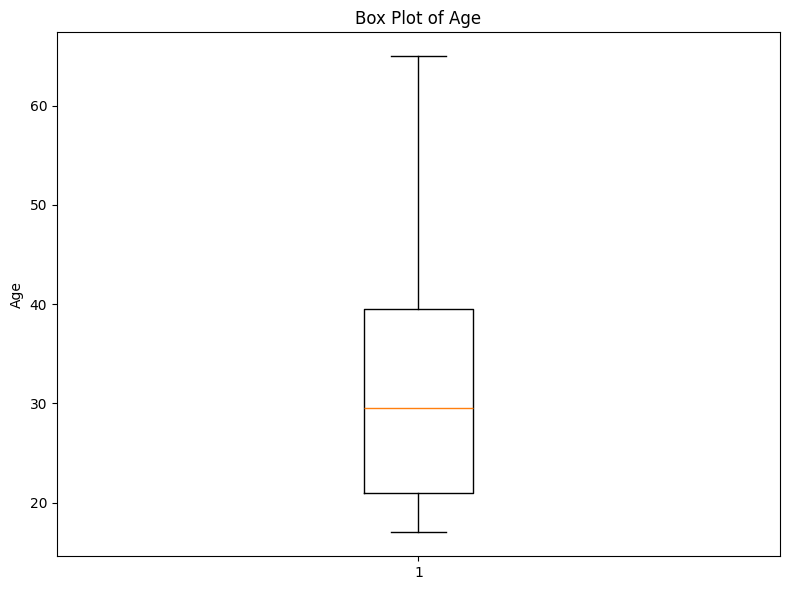

In [26]:
QUERY = """
SELECT Age
FROM main
WHERE Age IS NOT NULL
"""

df_age = pd.read_sql_query(QUERY, conn)

# Convert age groups into approximate numeric values
age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65
}

df_age["AgeNumeric"] = df_age["Age"].map(age_map)

# Remove missing values, including "Prefer not to say"
df_age = df_age.dropna(subset=["AgeNumeric"])

# Create box plot
plt.figure(figsize=(8, 6))

plt.boxplot(df_age["AgeNumeric"], vert=True, showfliers=True)

plt.title("Box Plot of Age")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


<Figure size 1200x600 with 0 Axes>

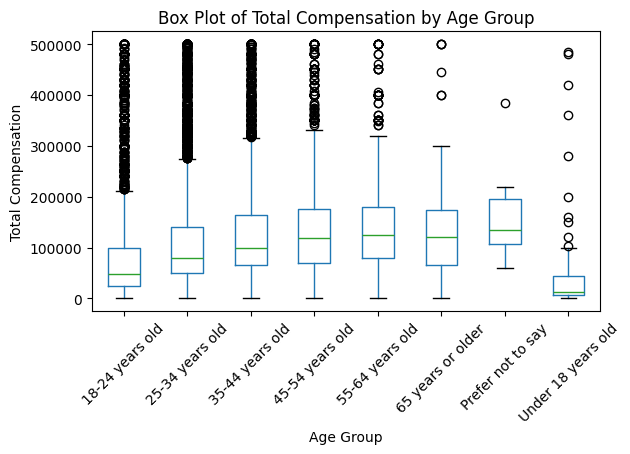

In [10]:
QUERY = """
SELECT Age, CompTotal
FROM main
WHERE Age IS NOT NULL
AND CompTotal IS NOT NULL
"""

df_box = pd.read_sql_query(QUERY, conn)

# Convert CompTotal to numeric
df_box["CompTotal"] = pd.to_numeric(df_box["CompTotal"], errors="coerce")

# Remove missing values
df_box = df_box.dropna(subset=["Age", "CompTotal"])

# Remove unrealistic/extreme compensation values
df_box = df_box[
    (df_box["CompTotal"] > 0) &
    (df_box["CompTotal"] <= 500000)
]

# Create box plot
plt.figure(figsize=(12, 6))

df_box.boxplot(
    column="CompTotal",
    by="Age",
    rot=45,
    grid=False
)

plt.title("Box Plot of Total Compensation by Age Group")
plt.suptitle("")  # removes the automatic pandas title
plt.xlabel("Age Group")
plt.ylabel("Total Compensation")

plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


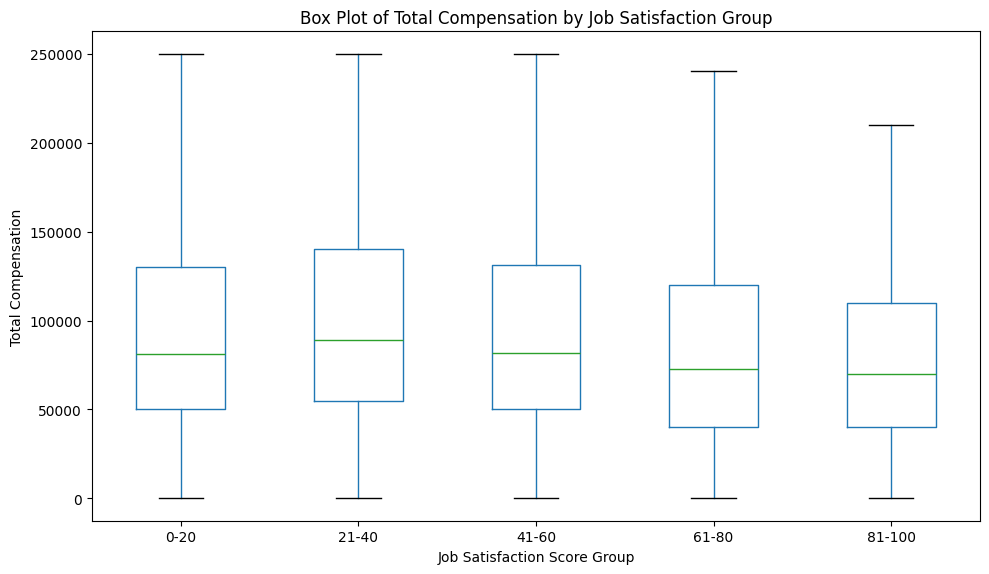

In [16]:
QUERY = """
SELECT JobSatPoints_6, CompTotal
FROM main
WHERE JobSatPoints_6 IS NOT NULL
AND CompTotal IS NOT NULL
"""

df_box_jobsat = pd.read_sql_query(QUERY, conn)

# Convert columns to numeric
df_box_jobsat["CompTotal"] = pd.to_numeric(df_box_jobsat["CompTotal"], errors="coerce")
df_box_jobsat["JobSatPoints_6"] = pd.to_numeric(df_box_jobsat["JobSatPoints_6"], errors="coerce")

# Remove missing values
df_box_jobsat = df_box_jobsat.dropna(subset=["CompTotal", "JobSatPoints_6"])

# Remove extreme compensation values
df_box_jobsat = df_box_jobsat[
    (df_box_jobsat["CompTotal"] > 0) &
    (df_box_jobsat["CompTotal"] <= 250000)
]

# Group job satisfaction into bands
df_box_jobsat["JobSatGroup"] = pd.cut(
    df_box_jobsat["JobSatPoints_6"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["0-20", "21-40", "41-60", "61-80", "81-100"],
    include_lowest=True
)

# Create box plot
df_box_jobsat.boxplot(
    column="CompTotal",
    by="JobSatGroup",
    figsize=(10, 6),
    grid=False,
    showfliers=False
)

plt.title("Box Plot of Total Compensation by Job Satisfaction Group")
plt.suptitle("")
plt.xlabel("Job Satisfaction Score Group")
plt.ylabel("Total Compensation")

plt.tight_layout()
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


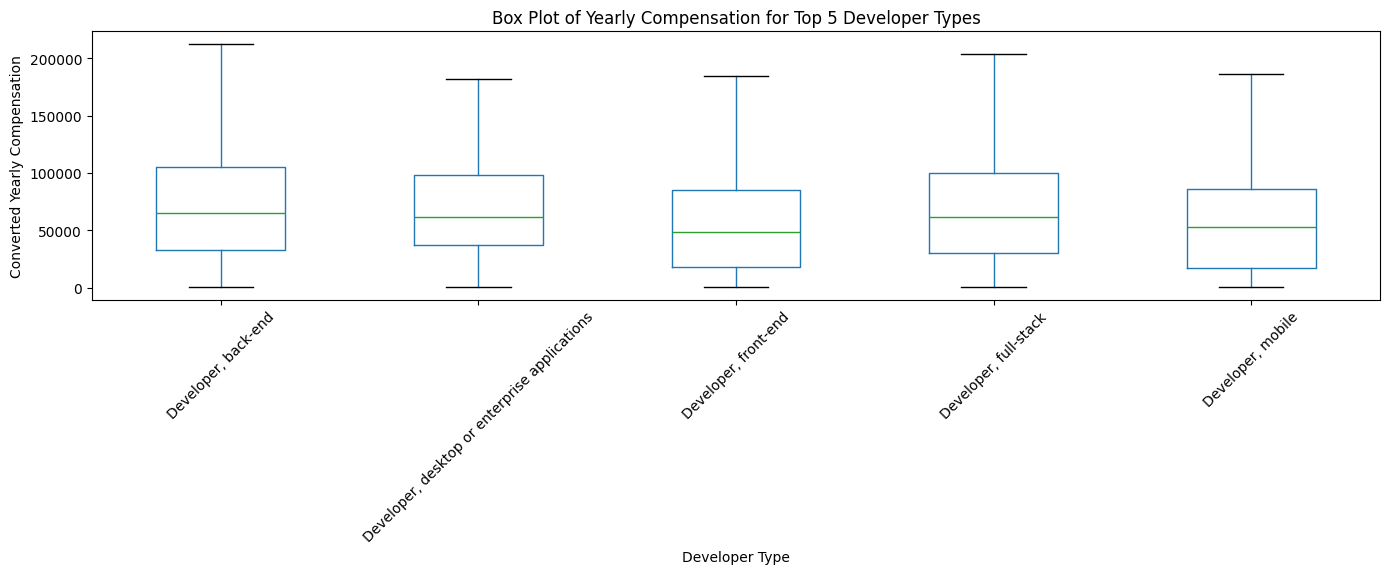

In [6]:
QUERY = """
SELECT DevType, ConvertedCompYearly
FROM main
WHERE DevType IS NOT NULL
AND ConvertedCompYearly IS NOT NULL
"""

df_dev = pd.read_sql_query(QUERY, conn)

# Convert compensation to numeric
df_dev["ConvertedCompYearly"] = pd.to_numeric(df_dev["ConvertedCompYearly"], errors="coerce")

# Remove missing values
df_dev = df_dev.dropna(subset=["DevType", "ConvertedCompYearly"])

# Split DevType because respondents can choose multiple roles
df_dev["DevType"] = df_dev["DevType"].str.split(";")
df_dev = df_dev.explode("DevType")

# Remove extra spaces
df_dev["DevType"] = df_dev["DevType"].str.strip()

# Find the top 5 developer types
top_5_devtypes = df_dev["DevType"].value_counts().head(5).index

# Keep only the top 5 developer types
df_top5 = df_dev[df_dev["DevType"].isin(top_5_devtypes)]

# Optional: remove extreme compensation values
df_top5 = df_top5[
    (df_top5["ConvertedCompYearly"] > 0) &
    (df_top5["ConvertedCompYearly"] <= 250000)
]

# Create box plot
df_top5.boxplot(
    column="ConvertedCompYearly",
    by="DevType",
    figsize=(14, 6),
    grid=False,
    showfliers=False,
    rot=45
)

plt.title("Box Plot of Yearly Compensation for Top 5 Developer Types")
plt.suptitle("")
plt.xlabel("Developer Type")
plt.ylabel("Converted Yearly Compensation")

plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


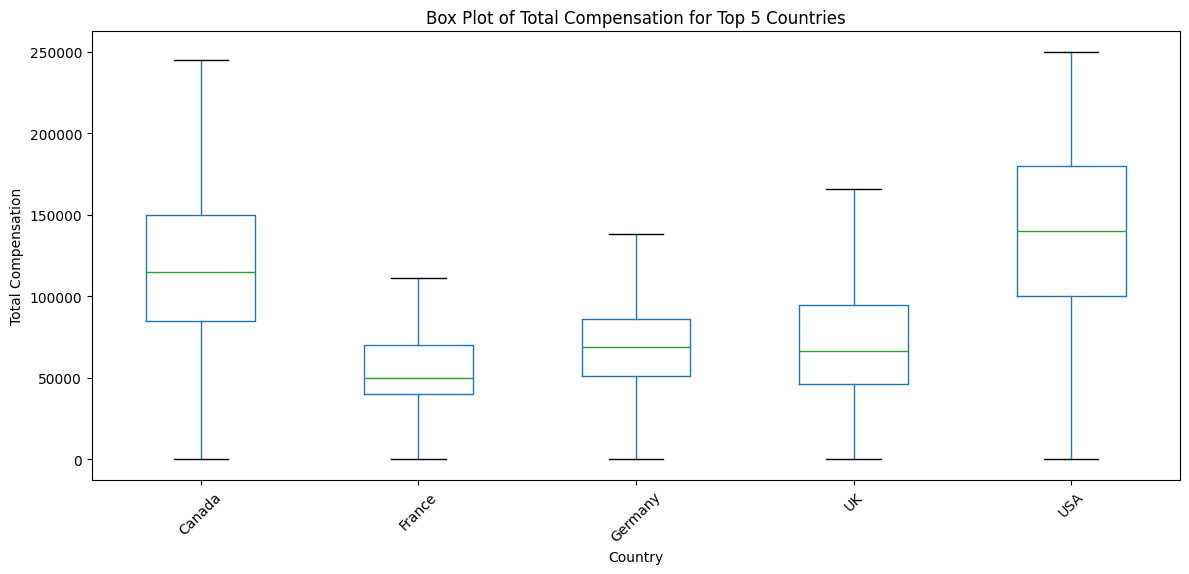

In [32]:
QUERY = """
SELECT Country, CompTotal
FROM main
WHERE Country IS NOT NULL
AND CompTotal IS NOT NULL
"""

df_country = pd.read_sql_query(QUERY, conn)

# Convert compensation to numeric
df_country["CompTotal"] = pd.to_numeric(df_country["CompTotal"], errors="coerce")

# Remove missing values
df_country = df_country.dropna(subset=["Country", "CompTotal"])

# Remove unrealistic/extreme compensation values
df_country = df_country[
    (df_country["CompTotal"] > 0) &
    (df_country["CompTotal"] <= 250000)
]

# Find the top 5 countries by number of respondents
top_5_countries = df_country["Country"].value_counts().head(5).index

# Keep only the top 5 countries
df_top5_countries = df_country[df_country["Country"].isin(top_5_countries)]

# Rename to UK and USA
df_top5_countries["Country"] = df_top5_countries["Country"].replace({
    "United States of America": "USA",
    "United Kingdom of Great Britain and Northern Ireland": "UK"
})

# Create the box plot
df_top5_countries.boxplot(
    column="CompTotal",
    by="Country",
    figsize=(12, 6),
    grid=False,
    showfliers=False,
    rot=45
)

plt.title("Box Plot of Total Compensation for Top 5 Countries")
plt.suptitle("")
plt.xlabel("Country")
plt.ylabel("Total Compensation")

plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


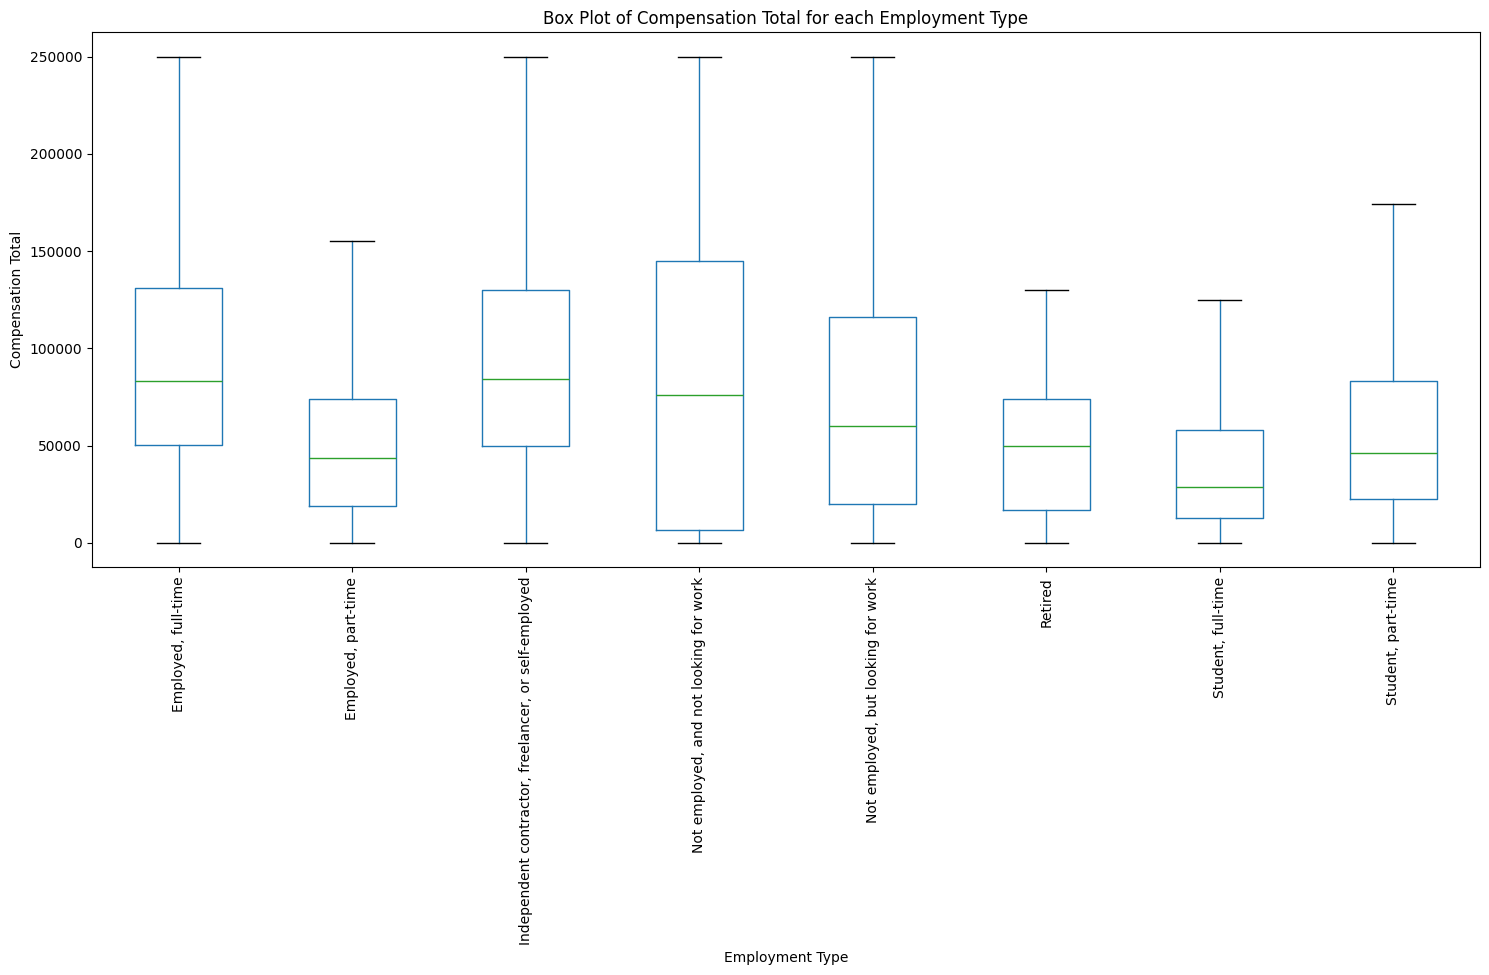

In [17]:
QUERY = """
SELECT CompTotal, Employment
FROM main
WHERE CompTotal IS NOT NULL
AND Employment IS NOT NULL
"""

df_employment_CT = pd.read_sql_query(QUERY, conn)

# Convert compensation to numeric
df_employment_CT["CompTotal"] = pd.to_numeric(df_employment_CT["CompTotal"], errors="coerce")

# Remove missing values
df_employment_CT = df_employment_CT.dropna(subset=["Employment", "CompTotal"])

# Remove unrealistic/extreme compensation values
df_employment_CT = df_employment_CT[
    (df_employment_CT["CompTotal"] > 0) &
    (df_employment_CT["CompTotal"] <= 250000)
]

# Split Employment because respondents can choose multiple employment types
df_employment_CT["Employment"] = df_employment_CT["Employment"].str.split(";")
df_employment_CT = df_employment_CT.explode("Employment")

# Remove extra spaces
df_employment_CT["Employment"] = df_employment_CT["Employment"].str.strip()

df_employment_CT.boxplot(
    column="CompTotal",
    by="Employment",
    figsize=(15, 10),
    grid=False,
    showfliers=False,
    rot=90
)

plt.title("Box Plot of Compensation Total for each Employment Type")
plt.suptitle("")
plt.xlabel("Employment Type")
plt.ylabel("Compensation Total")

plt.tight_layout()
plt.show()


**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


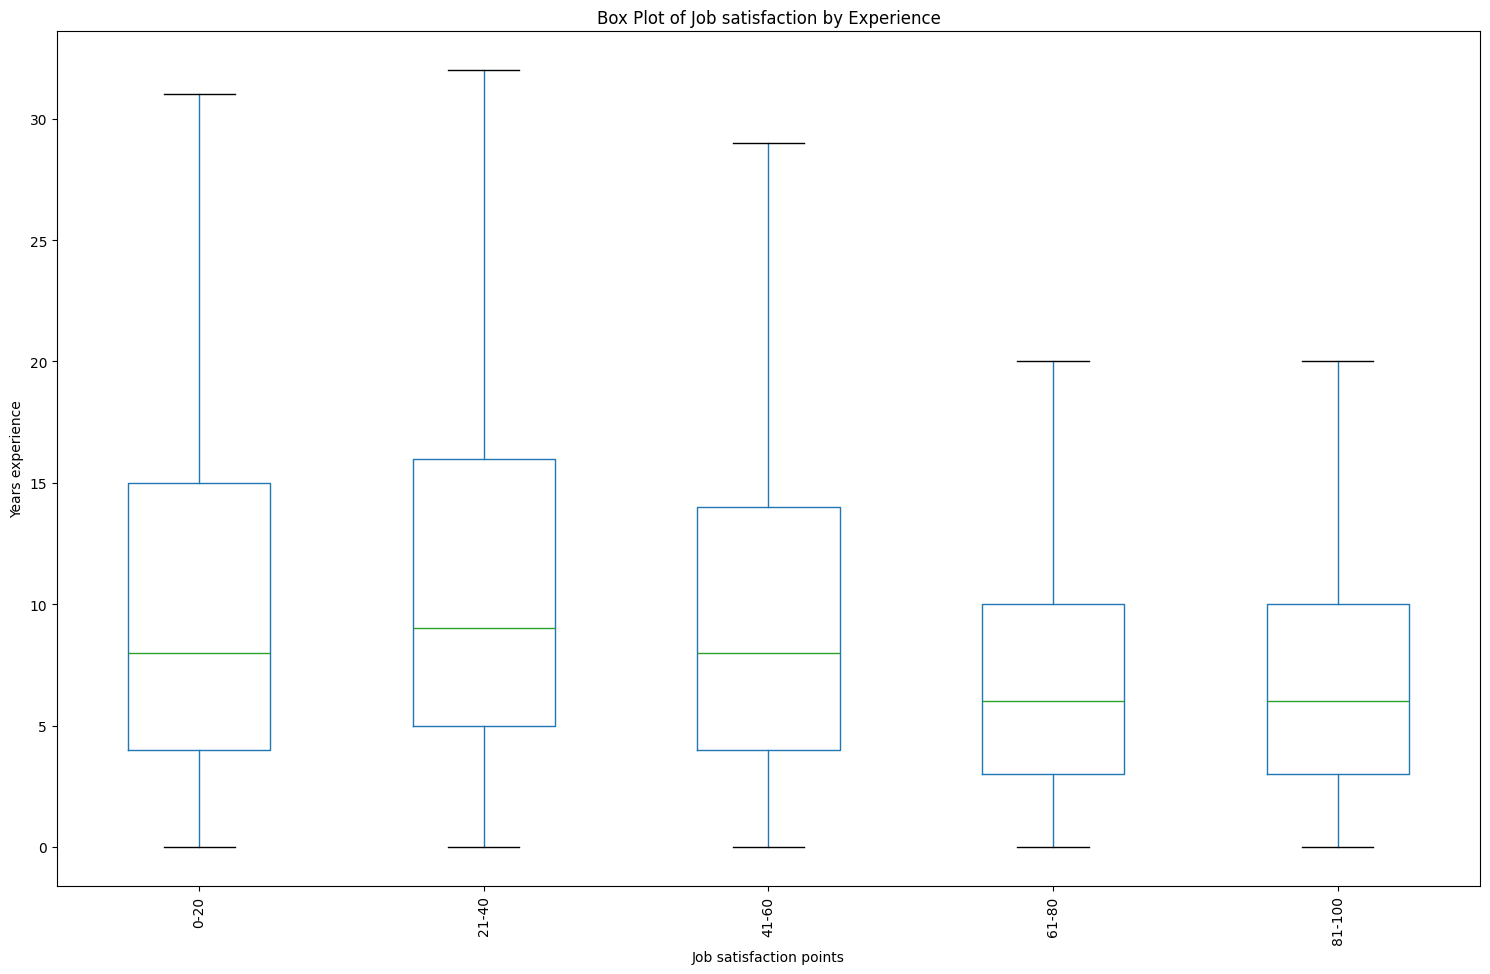

In [22]:
QUERY = """
SELECT YearsCodePro, JobSatPoints_6
FROM main
WHERE YearsCodePro IS NOT NULL
AND JobSatPoints_6 IS NOT NULL
"""

df_YCP_JSP = pd.read_sql_query(QUERY, conn)

# Convert YearsCodePro into numbers
df_YCP_JSP["YearsCodePro"] = df_YCP_JSP["YearsCodePro"].replace({
    "Less than 1 year": 0,
    "More than 50 years": 51
})

# Convert compensation to numeric
df_YCP_JSP["YearsCodePro"] = pd.to_numeric(df_YCP_JSP["YearsCodePro"], errors="coerce")
df_YCP_JSP["JobSatPoints_6"] = pd.to_numeric(df_YCP_JSP["JobSatPoints_6"], errors="coerce")

# Create job satisfaction groups
df_YCP_JSP["JobSatPoints_6"] = pd.cut(
    df_YCP_JSP["JobSatPoints_6"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["0-20", "21-40", "41-60", "61-80", "81-100"],
    include_lowest=True
)

# Remove missing values
df_YCP_JSP = df_YCP_JSP.dropna(subset=["YearsCodePro", "JobSatPoints_6"])

df_YCP_JSP.boxplot(
    column="YearsCodePro",
    by="JobSatPoints_6",
    figsize=(15, 10),
    grid=False,
    showfliers=False,
    rot=90
)

plt.title("Box Plot of Job satisfaction by Experience")
plt.suptitle("")
plt.xlabel("Job satisfaction points")
plt.ylabel("Years experience")

plt.tight_layout()
plt.show()


Examine the distribution of professional coding years by job satisfaction levels.


<p>The chart shows the distribution of professional coding experience across job satisfaction groups. The median years of experience appear broadly similar across the groups, suggesting there is no clear relationship between job satisfaction and coding experience. Some groups have a wider range of experience, indicating that respondents with similar satisfaction levels can have very different career lengths.</p>

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [ ]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
